In [1]:
import pandas as pd
import plotly.express as px
from django.contrib.admin import display
from sqlalchemy               import (create_engine)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
from sklearn.model_selection  import train_test_split
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import classification_report,roc_auc_score, confusion_matrix
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.naive_bayes      import BernoulliNB
from xgboost                  import XGBClassifier

In [2]:
inpatient_path = r"C:\Users\Νίκος\Documents\N'work\thesis\Git_Repository\medicare-data-mining\data\raw\2015_2025\inpatient.csv"

inpatient_df = pd.read_csv(inpatient_path, sep="|", low_memory=False)

print(inpatient_df.shape)
print(inpatient_df.columns[:20])

(58066, 197)
Index(['BENE_ID', 'CLM_ID', 'NCH_NEAR_LINE_REC_IDENT_CD', 'NCH_CLM_TYPE_CD',
       'CLM_FROM_DT', 'CLM_THRU_DT', 'NCH_WKLY_PROC_DT', 'FI_CLM_PROC_DT',
       'CLAIM_QUERY_CODE', 'PRVDR_NUM', 'CLM_FAC_TYPE_CD',
       'CLM_SRVC_CLSFCTN_TYPE_CD', 'CLM_FREQ_CD', 'FI_NUM',
       'CLM_MDCR_NON_PMT_RSN_CD', 'CLM_PMT_AMT', 'NCH_PRMRY_PYR_CLM_PD_AMT',
       'NCH_PRMRY_PYR_CD', 'FI_CLM_ACTN_CD', 'PRVDR_STATE_CD'],
      dtype='str')


In [3]:
inpatient_df.columns = (
    inpatient_df.columns
        .str.lower()
        .str.strip()
)
inpatient_df.columns[:20]

Index(['bene_id', 'clm_id', 'nch_near_line_rec_ident_cd', 'nch_clm_type_cd',
       'clm_from_dt', 'clm_thru_dt', 'nch_wkly_proc_dt', 'fi_clm_proc_dt',
       'claim_query_code', 'prvdr_num', 'clm_fac_type_cd',
       'clm_srvc_clsfctn_type_cd', 'clm_freq_cd', 'fi_num',
       'clm_mdcr_non_pmt_rsn_cd', 'clm_pmt_amt', 'nch_prmry_pyr_clm_pd_amt',
       'nch_prmry_pyr_cd', 'fi_clm_actn_cd', 'prvdr_state_cd'],
      dtype='str')

In [4]:
inpatient_df["bene_id"] = inpatient_df["bene_id"].astype(str)

In [5]:
inpatient_df["clm_from_dt"] = pd.to_datetime(
    inpatient_df["clm_from_dt"],
    errors="coerce"
)

inpatient_df["year"] = inpatient_df["clm_from_dt"].dt.year
inpatient_df["year"].value_counts().sort_index()

year
2015     4050
2016     4928
2017     5515
2018     6297
2019     6791
2020     8775
2021     9249
2022    10598
2023     1863
Name: count, dtype: int64

In [6]:
money_cols = [
    "clm_pmt_amt",
    "clm_tot_chrg_amt",
    "nch_bene_ip_ddctbl_amt",
    "nch_bene_pta_coinsrnc_lblty_am"
]

for col in money_cols:
    if col in inpatient_df.columns:
        inpatient_df[col] = pd.to_numeric(inpatient_df[col], errors="coerce")

In [7]:
annual_cost = (
    inpatient_df
        .groupby(["bene_id", "year"])[money_cols]
        .sum()
        .reset_index()
)

In [8]:
annual_cost = annual_cost.rename(columns={
    "clm_pmt_amt": "total_inpatient_paid",
    "clm_tot_chrg_amt": "total_inpatient_charge",
    "nch_bene_ip_ddctbl_amt": "total_deductible",
    "nch_bene_pta_coinsrnc_lblty_am": "total_coinsurance"
})

In [9]:
annual_cost.describe()

,year,total_inpatient_paid,total_inpatient_charge,total_deductible,total_coinsurance
count,11545.000000,1.154500e+04,1.154500e+04,11545.000000,1.154500e+04
mean,2018.989259,6.859437e+04,6.859437e+04,48.237660,9.530741e+03
std,2.343299,5.776398e+05,5.776398e+05,440.049702,8.080733e+04
min,2015.000000,6.244000e+01,6.244000e+01,0.000000,0.000000e+00
25%,2017.000000,1.650000e+02,1.650000e+02,0.000000,0.000000e+00
50%,2019.000000,5.859360e+03,5.859360e+03,0.000000,6.342000e+01
75%,2021.000000,2.388212e+04,2.388212e+04,0.000000,2.937280e+03
max,2023.000000,2.572090e+07,2.572090e+07,16818.880000,3.656424e+06


In [10]:
dx_cols = [c for c in inpatient_df.columns if "dgns" in c]

print(dx_cols[:10])

['admtg_dgns_cd', 'prncpal_dgns_cd', 'icd_dgns_cd1', 'icd_dgns_cd2', 'icd_dgns_cd3', 'icd_dgns_cd4', 'icd_dgns_cd5', 'icd_dgns_cd6', 'icd_dgns_cd7', 'icd_dgns_cd8']


In [11]:
inpatient_df[dx_cols] = (
    inpatient_df[dx_cols]
        .fillna("")
        .astype(str)
        .apply(lambda x: x.str.strip())
)

In [13]:
disease_map = {
    "diabetes": r"\bE1[0-4]",
    "ckd": r"\bN18",
    "chf": r"\bI50",
    "copd": r"\bJ44",
    "cancer": r"\bC",
    "stroke": r"\bI6[3-4]"
}

In [14]:
for disease, pattern in disease_map.items():
    inpatient_df[disease] = (
        inpatient_df[dx_cols]
            .apply(lambda col: col.str.contains(pattern, regex=True, na=False))
            .any(axis=1)
            .astype(int)
    )

In [15]:
disease_flags = (
    inpatient_df
        .groupby(["bene_id", "year"])[list(disease_map.keys())]
        .max()
        .reset_index()
)

In [16]:
annual_cost = (
    inpatient_df
        .groupby(["bene_id", "year"])["clm_pmt_amt"]
        .sum()
        .reset_index()
)

In [17]:
annual_cost = annual_cost.rename(columns={
    "clm_pmt_amt": "total_inpatient_paid"
})

In [18]:
model_df = annual_cost.merge(
    disease_flags,
    on=["bene_id", "year"],
    how="left"
).fillna(0)

In [19]:
disease_cols = list(disease_map.keys())

model_df["comorbidity_count"] = model_df[disease_cols].sum(axis=1)

In [20]:
model_df.groupby("comorbidity_count")["total_inpatient_paid"].mean()

comorbidity_count
0     34597.927688
1    107841.661110
2     69017.836351
3    432937.503442
4    177606.320000
Name: total_inpatient_paid, dtype: float64

In [21]:
model_df["high_cost_flag"] = (
    model_df
        .groupby("year")["total_inpatient_paid"]
        .transform(lambda x: x >= x.quantile(0.95))
        .astype(int)
)
model_df["high_cost_flag"].value_counts()

high_cost_flag
0    10964
1      581
Name: count, dtype: int64

In [23]:
model_df.sort_values("total_inpatient_paid", ascending=False).head(10)

,bene_id,year,total_inpatient_paid,diabetes,ckd,chf,copd,cancer,stroke,comorbidity_count,high_cost_flag
5977,-10000010271384,2020,25720895.06,0,0,0,0,1,0,1,1
3629,-10000010264641,2022,19454109.68,1,0,0,0,1,0,2,1
1945,-10000010259769,2021,18282120.06,1,1,0,0,1,0,3,1
3881,-10000010265392,2022,16785460.22,0,0,0,0,1,0,1,1
9243,-10000010280870,2022,15787070.98,0,0,0,0,1,0,1,1
5979,-10000010271384,2022,14061334.76,0,0,0,0,1,0,1,1
2045,-10000010260059,2022,13224979.60,0,0,0,0,1,0,1,1
9214,-10000010280747,2022,11567472.80,0,0,0,0,1,0,1,1
8350,-10000010277912,2021,10611675.74,1,1,0,0,1,0,3,1
8211,-10000010277596,2022,9377179.68,0,0,0,0,1,0,1,1


In [25]:
feature_cols = [
    "diabetes",
    "ckd",
    "chf",
    "copd",
    "cancer",
    "stroke",
    "comorbidity_count"
]

X = model_df[feature_cols]
y = model_df["high_cost_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [26]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [27]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [28]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      0.74      0.84      3290
           1       0.06      0.33      0.11       174

    accuracy                           0.72      3464
   macro avg       0.51      0.54      0.47      3464
weighted avg       0.91      0.72      0.80      3464

ROC-AUC: 0.5524324843657198


In [29]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
4,cancer,0.330357
6,comorbidity_count,0.182840
3,copd,0.144340
0,diabetes,0.139765
2,chf,0.105978
1,ckd,0.096720
5,stroke,0.000000


Το μοντέλο XGBoost δεν ξεπέρασε σημαντικά την λογιστική παλινδρόμηση (ROC-AUC = 0,552 έναντι 0,576), υποδεικνύοντας ότι η περιορισμένη προγνωστική απόδοση οφείλεται κυρίως στον περιορισμένο χώρο χαρακτηριστικών και όχι στην πολυπλοκότητα του μοντέλου.

Ο καρκίνος και το συνολικό βάρος συννοσηρότητας αναδείχθηκαν ως οι ισχυρότεροι προγνωστικοί παράγοντες υψηλού κόστους, υπογραμμίζοντας τη σημασία της σοβαρότητας της νόσου και της πολυνοσηρότητας στις δαπάνες νοσηλείας.

Ωστόσο, οι δυαδικοί δείκτες συννοσηρότητας από μόνοι τους φαίνονται ανεπαρκείς για μια ισχυρή πρόβλεψη υψηλού κόστους.
Τα αποτελέσματα σε σχέση με τη λογιστική παλινδρόμηση είναι απογοητευτικά με recall στο 33% και precision στο 6%.

In [24]:
xgb_results = []

feature_cols = [
    "diabetes",
    "ckd",
    "chf",
    "copd",
    "cancer",
    "stroke",
    "comorbidity_count"
]

for yr in sorted(model_df["year"].unique()):

    df_year = model_df[model_df["year"] == yr]

    # Αν δεν έχει αρκετά positives skip
    if df_year["high_cost_flag"].sum() < 20:
        continue

    X = df_year[feature_cols]
    y = df_year["high_cost_flag"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    )

    xgb_model.fit(X_train, y_train)

    y_prob = xgb_model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    xgb_results.append({
        "year": yr,
        "n_obs": len(df_year),
        "auc": auc
    })

xgb_results_df = pd.DataFrame(xgb_results)
xgb_results_df

,year,n_obs,auc
0,2015,1003,0.579021
1,2016,1227,0.572782
2,2017,1270,0.495420
3,2018,1378,0.670908
4,2019,1419,0.525220
5,2020,1529,0.527224
6,2021,1617,0.499504
7,2022,1684,0.582011
8,2023,418,0.913194


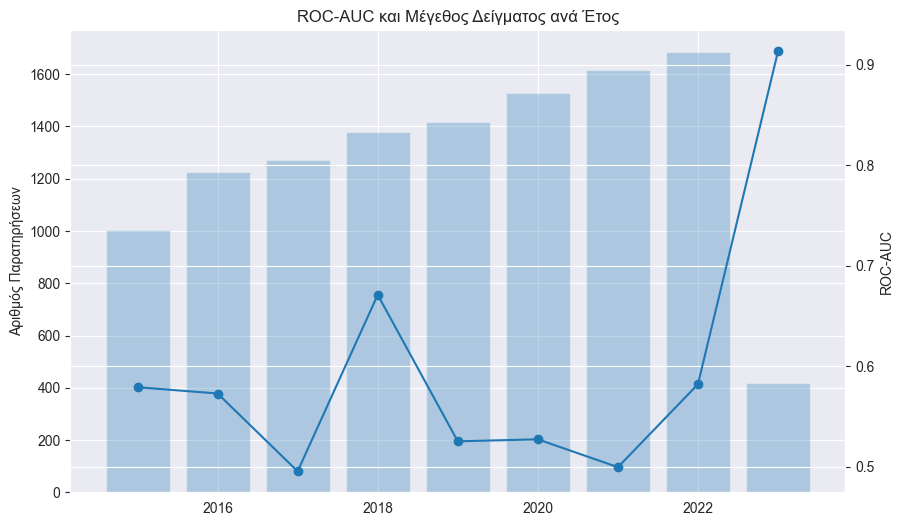

In [31]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(xgb_results_df["year"], xgb_results_df["n_obs"], alpha=0.3)
ax1.set_ylabel("Αριθμός Παρατηρήσεων")

ax2 = ax1.twinx()
ax2.plot(xgb_results_df["year"], xgb_results_df["auc"], marker="o")
ax2.set_ylabel("ROC-AUC")

plt.title("ROC-AUC και Μέγεθος Δείγματος ανά Έτος")
plt.show()